Step 1: Load dataset

In [2]:
import pandas as pd

df = pd.read_csv("uci-ml-phishing-dataset.csv")
print(df.head())
print(df.shape)

   id  having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0   1                 -1           1                   1                 1   
1   2                  1           1                   1                 1   
2   3                  1           0                   1                 1   
3   4                  1           0                   1                 1   
4   5                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  ...  popUpWi

Step 2: Check columns

In [3]:

df = df.drop(columns=['id'])   # or whatever name you see
print(df.columns)

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')


Step 3: Split features & labels

In [4]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

Step 4: Convert labels

In [5]:
import numpy as np
y = np.where(y == -1, 0, 1)

Step 5: Train-test split + scaling


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 6: Deep Learning Model (TensorFlow)

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 7: Train

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8788 - loss: 0.2870 - val_accuracy: 0.9299 - val_loss: 0.1676
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9303 - loss: 0.1798 - val_accuracy: 0.9345 - val_loss: 0.1547
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9343 - loss: 0.1613 - val_accuracy: 0.9469 - val_loss: 0.1435
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9421 - loss: 0.1444 - val_accuracy: 0.9469 - val_loss: 0.1346
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9447 - loss: 0.1364 - val_accuracy: 0.9559 - val_loss: 0.1295
Epoch 6/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9481 - loss: 0.1299 - val_accuracy: 0.9537 - val_loss: 0.1254
Epoch 7/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9470 - loss: 0.1230 - val_accuracy: 0.9559 - val_loss: 0.1271
Epoch 8/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9500 - loss: 0.1159 - val_accuracy: 0.

In [9]:
import pickle
pickle.dump(model, open("model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))
model.save("model.h5")


Step 8: Evaluate

In [10]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9634 - loss: 0.1044
Test Accuracy: 0.9633650183677673


In [11]:
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction > 0.5:
    print("Legitimate Website")
else:
    print("Phishing Website")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Phishing Website


Confusion Matrix

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
 [[ 900   56]
 [  25 1230]]


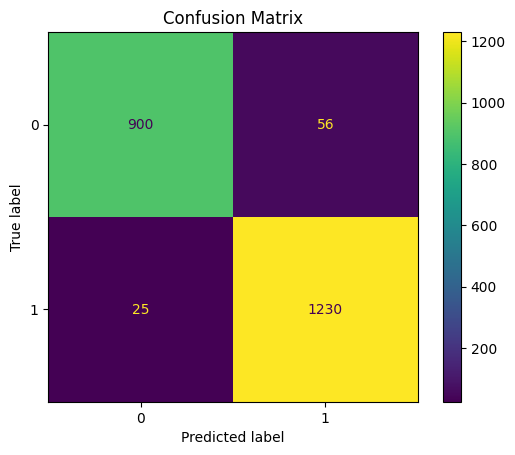

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict(X_test)

# Convert to 0/1
y_pred = (y_prob > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

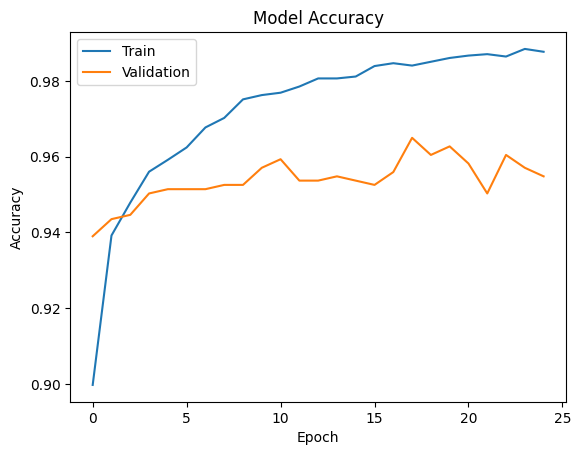

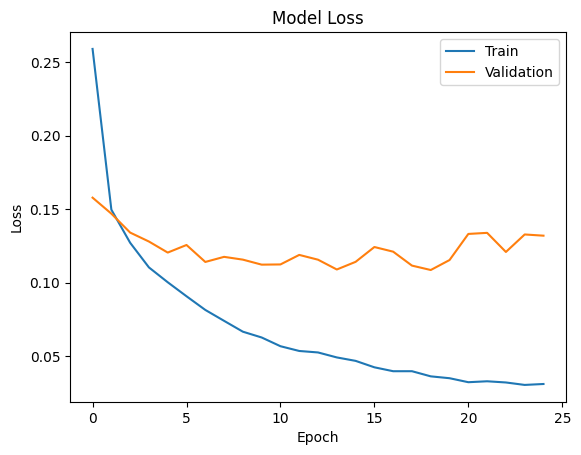

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import re
import socket
import requests
import pickle
from urllib.parse import urlparse

# ------------------ LOAD MODEL + SCALER ------------------
# Save these after training:
# pickle.dump(model, open("model.pkl","wb"))
# pickle.dump(scaler, open("scaler.pkl","wb"))

model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# ------------------ FEATURE EXTRACTOR ------------------
def extract_features(url):
    features = []

    parsed = urlparse(url)
    hostname = parsed.netloc

    # 1 IP Address
    try:
        socket.inet_aton(hostname)
        features.append(-1)
    except:
        features.append(1)

    # 2 URL Length
    features.append(1 if len(url) < 54 else 0 if len(url) <= 75 else -1)

    # 3 Shortening
    features.append(-1 if re.search(r"bit\.ly|tinyurl|t\.co", url) else 1)

    # 4 @ symbol
    features.append(-1 if "@" in url else 1)

    # 5 //
    features.append(-1 if "//" in url[7:] else 1)

    # 6 Hyphen
    features.append(-1 if "-" in hostname else 1)

    # 7 Subdomain
    dots = hostname.count(".")
    features.append(1 if dots == 1 else 0 if dots == 2 else -1)

    # 8 HTTPS
    features.append(1 if url.startswith("https") else -1)

    # 9–12 dummy/basic
    features += [0, 0]
    features.append(1 if parsed.port in [None, 80, 443] else -1)
    features.append(-1 if "https" in hostname else 1)

    # -------- content-based --------
    try:
        response = requests.get(url, timeout=3)
        content = response.text
        redirects = len(response.history)
    except:
        content = ""
        redirects = 0

    features.append(1 if "src" in content else 0)
    features.append(1 if "<a" in content else 0)
    features.append(1 if "<link" in content else 0)
    features.append(-1 if "about:blank" in content else 1)
    features.append(-1 if "mailto:" in content else 1)
    features.append(1 if hostname in url else -1)
    features.append(-1 if redirects > 2 else 1)
    features.append(-1 if "onmouseover" in content else 1)
    features.append(-1 if "event.button==2" in content else 1)
    features.append(-1 if "alert(" in content else 1)
    features.append(-1 if "<iframe" in content else 1)

    # Remaining placeholders
    features += [0] * 7

    return features


# ------------------ MAIN ------------------
while True:
    url = input("\nEnter URL (or type 'exit'): ")

    if url == "exit":
        break

    try:
        features = extract_features(url)
        features = np.array(features).reshape(1, -1)

        features = scaler.transform(features)
        prediction = model.predict(features)[0][0]

        print("\n🔍 Prediction Score:", prediction)

        if prediction > 0.5:
            print("✅ Legitimate Website")
        else:
            print("⚠️ Phishing Website")

    except Exception as e:
        print("Error:", e)


Enter URL (or type 'exit'): https://colab.research.google.com/drive/1PG62IGxq6tYSuO5Wr9-X5H9xiUbTFqqT#scrollTo=cYSdZ63XJ1YO
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

🔍 Prediction Score: 1.0
✅ Legitimate Website

Enter URL (or type 'exit'): http://secure-login-bank.com/login?user=admin'--&pass=123
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

🔍 Prediction Score: 0.00053115643
⚠️ Phishing Website

Enter URL (or type 'exit'): http://paypal-secure-update.com/verify
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

🔍 Prediction Score: 0.0010322885
⚠️ Phishing Website

Enter URL (or type 'exit'): http://account-update-security-check.com/verify/user/session/update/login/index.php?id=984723984723984723
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

🔍 Prediction Score: 0.00068410224
⚠️ Phishing Website

Enter URL (or type 'exit'): https://www.amazon.in/gp/cart/view.html?ref_=nav_cart&session-id=123-4567890-1234567
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

🔍 Prediction Score: 1.0
✅ Legitimate Website


KeyboardInterrupt: Interrupted by user